In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


# EMNIST Transform

In [3]:
transform_emnist = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: torch.rot90(x, 1, [1,2])),
    transforms.Lambda(lambda x: torch.flip(x, [2])),
    transforms.Normalize((0.5,), (0.5,))
])

# Load EMNIST

In [4]:
train_dataset = torchvision.datasets.EMNIST(
    root='./data',
    split='letters',
    train=True,
    transform=transform_emnist,
    download=True
)

test_dataset = torchvision.datasets.EMNIST(
    root='./data',
    split='letters',
    train=False,
    transform=transform_emnist,
    download=True
)

print(len(train_dataset), len(test_dataset))

100%|██████████| 562M/562M [00:04<00:00, 115MB/s]  


124800 20800


# Sequence Conversion

In [5]:
def image_to_sequence(image):
    return image.squeeze(0)  # row-wise

# Custom dataset

In [6]:
class EMNISTSequence(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        image = image_to_sequence(image)
        label = label - 1   # 🔥 VERY IMPORTANT (1–26 → 0–25)
        return image, label

# DataLoader

In [7]:
train_loader = torch.utils.data.DataLoader(
    EMNISTSequence(train_dataset),
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    EMNISTSequence(test_dataset),
    batch_size=64,
    shuffle=False
)

# RNN Model

In [8]:
class RNNModel(nn.Module):
    def __init__(self, input_size=28, hidden_size=128, num_layers=1, num_classes=26):
        super(RNNModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)

        out, _ = self.rnn(x, h0)
        out = out[:, -1, :]
        out = self.fc(out)

        return out

# Training + Evaluation

In [9]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, pred = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (pred == labels).sum().item()

    return 100 * correct / total

In [12]:
def train(model, train_loader, test_loader, epochs=10):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    loss_list = []
    train_acc_list = []
    val_acc_list = []

    for epoch in range(epochs):
        model.train()

        total_loss = 0
        correct = 0
        total = 0

        start_time = time.time()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            # 🔥 Train accuracy
            _, pred = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (pred == labels).sum().item()

        # Metrics
        avg_loss = total_loss / len(train_loader)
        train_acc = 100 * correct / total
        val_acc = evaluate(model, test_loader)

        end_time = time.time()

        # Store
        loss_list.append(avg_loss)
        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)

        # 🔥 Print in your desired format
        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Time: {end_time - start_time:.2f}s")

    return loss_list, train_acc_list, val_acc_list

In [15]:
model = RNNModel().to(device)

losses, train_accs, val_accs = train(model, train_loader, test_loader, epochs=10)

Epoch [1/10] | Loss: 1.5717 | Train Acc: 51.28% | Val Acc: 67.49% | Time: 39.84s
Epoch [2/10] | Loss: 0.8593 | Train Acc: 73.73% | Val Acc: 77.10% | Time: 39.73s
Epoch [3/10] | Loss: 0.7205 | Train Acc: 78.21% | Val Acc: 76.76% | Time: 39.42s
Epoch [4/10] | Loss: 0.6573 | Train Acc: 80.11% | Val Acc: 80.88% | Time: 39.33s
Epoch [5/10] | Loss: 0.6190 | Train Acc: 81.39% | Val Acc: 81.34% | Time: 39.53s
Epoch [6/10] | Loss: 0.5919 | Train Acc: 82.23% | Val Acc: 82.14% | Time: 39.24s
Epoch [7/10] | Loss: 0.5757 | Train Acc: 82.68% | Val Acc: 82.60% | Time: 39.23s
Epoch [8/10] | Loss: 0.5795 | Train Acc: 82.51% | Val Acc: 82.06% | Time: 39.64s
Epoch [9/10] | Loss: 0.5557 | Train Acc: 83.27% | Val Acc: 84.06% | Time: 39.59s
Epoch [10/10] | Loss: 0.5630 | Train Acc: 83.12% | Val Acc: 82.52% | Time: 39.49s


# Plot Curves


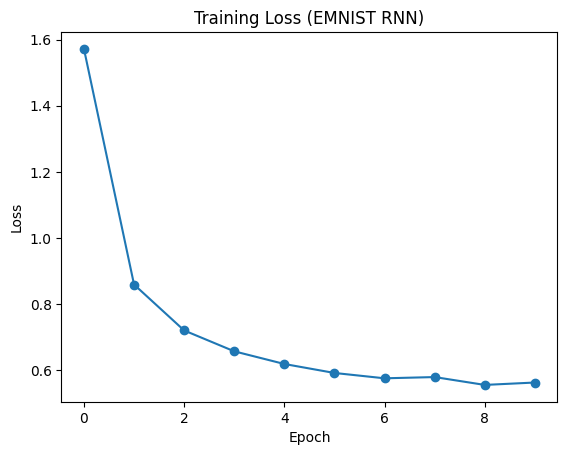

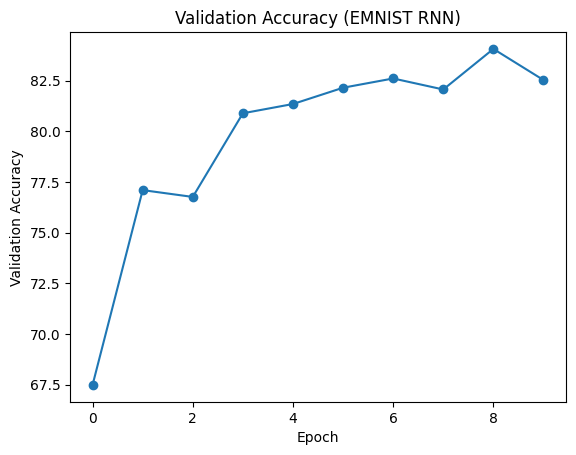

In [16]:
# Loss curve
plt.figure()
plt.plot(losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss (EMNIST RNN)")
plt.show()

# Accuracy curve
plt.figure()
plt.plot(val_accs, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy (EMNIST RNN)")
plt.show()

# Predictions (for metrics)

In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def get_predictions(model, loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            _, pred = torch.max(outputs, 1)

            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(labels.numpy())

    return all_labels, all_preds

# Classification Report and confusion matrix 

Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.73      0.73       800
           1       0.75      0.90      0.82       800
           2       0.88      0.88      0.88       800
           3       0.81      0.81      0.81       800
           4       0.86      0.87      0.86       800
           5       0.92      0.85      0.89       800
           6       0.79      0.52      0.63       800
           7       0.86      0.77      0.81       800
           8       0.64      0.71      0.67       800
           9       0.86      0.81      0.83       800
          10       0.85      0.85      0.85       800
          11       0.68      0.67      0.68       800
          12       0.90      0.93      0.92       800
          13       0.85      0.80      0.82       800
          14       0.84      0.91      0.87       800
          15       0.89      0.90      0.90       800
          16       0.66      0.74      0.69       800
   

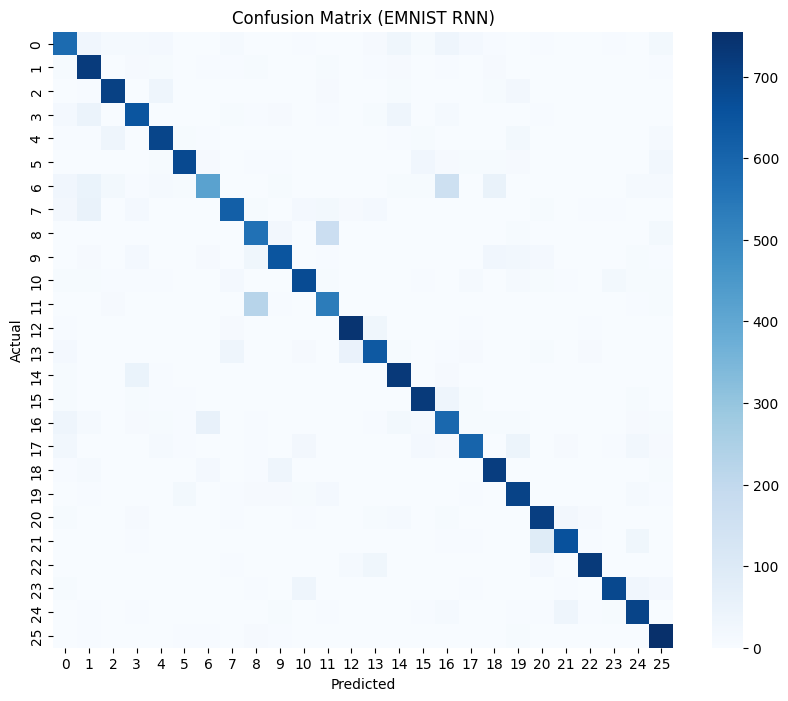

In [18]:
labels, preds = get_predictions(model, test_loader)

print("Classification Report:\n")
print(classification_report(labels, preds))

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap='Blues')
plt.title("Confusion Matrix (EMNIST RNN)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report

    The model achieves moderate precision and recall across classes, with some confusion among visually similar characters.

# Confusion Matrix

    The confusion matrix shows that most predictions lie along the diagonal, but misclassifications occur between similar-looking characters.

# Observation

    “The RNN model achieves lower accuracy on EMNIST compared to MNIST due to increased complexity and a larger number of classes.”

# Reason

    “EMNIST contains more classes and greater variation in handwritten characters, making classification more challenging.”